In [1]:
!pip install optuna xgboost shap

  Using cached optuna-4.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
Using cached optuna-4.9.0-py3-none-any.whl (425 kB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import optuna

import shap

In [3]:
df = pd.read_csv("../Data/online_retail_feature_engineered.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,...,AverageSpend,LifetimeSales,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
3,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345
4,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,2009,12,...,28.4544,2134.08,13085.0,158,8,2134.08,3,4,5,345


In [4]:
df["Churn"] = np.where(df["Recency"] > 90,1,0)

In [5]:
features = [

    "Recency",

    "Frequency",

    "Monetary"

]

X = df[features]

y = df["Churn"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [7]:
def objective(trial):

    params={

        "n_estimators":trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth":trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate":trial.suggest_float(
            "learning_rate",
            0.01,
            0.30
        ),

        "subsample":trial.suggest_float(
            "subsample",
            0.60,
            1.00
        ),

        "colsample_bytree":trial.suggest_float(
            "colsample_bytree",
            0.60,
            1.00
        ),

        "gamma":trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "random_state":42,

        "eval_metric":"logloss"

    }

    model = XGBClassifier(**params)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test,pred)

    return score

In [10]:
study = optuna.create_study(

    direction="maximize"

)

study.optimize(

    objective,

    n_trials=30

)

[I 2026-06-29 14:32:26,052] A new study created in memory with name: no-name-340e68d9-6f75-4ad6-af46-4740f52a2e11
[I 2026-06-29 14:32:34,240] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 442, 'max_depth': 5, 'learning_rate': 0.09051014843005623, 'subsample': 0.7389277516346827, 'colsample_bytree': 0.7243503753356733, 'gamma': 2.706653565354017}. Best is trial 0 with value: 1.0.
[I 2026-06-29 14:32:41,212] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 321, 'max_depth': 10, 'learning_rate': 0.2978846856121451, 'subsample': 0.6215556093541855, 'colsample_bytree': 0.8411756161772037, 'gamma': 0.3939018506200753}. Best is trial 0 with value: 1.0.
[I 2026-06-29 14:32:50,282] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 429, 'max_depth': 8, 'learning_rate': 0.19911266965503918, 'subsample': 0.7259957476365695, 'colsample_bytree': 0.6818988953539179, 'gamma': 0.3835167330506928}. Best is trial 0 with value: 1.0.
[I 2026-06-29 14:32:

In [11]:
print("Best Accuracy :",study.best_value)

print()

print("Best Parameters")

study.best_params

Best Accuracy : 1.0

Best Parameters


{'n_estimators': 442,
 'max_depth': 5,
 'learning_rate': 0.09051014843005623,
 'subsample': 0.7389277516346827,
 'colsample_bytree': 0.7243503753356733,
 'gamma': 2.706653565354017}

In [12]:
best_model = XGBClassifier(

    **study.best_params,

    random_state=42,

    eval_metric="logloss"

)

best_model.fit(

    X_train,

    y_train

)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7243503753356733, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=2.706653565354017, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.09051014843005623,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=442, n_jobs=None,
              num_parallel_tree=None, ...)

In [13]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

In [14]:
accuracy = accuracy_score(

    y_test,

    y_pred

)

print("Accuracy :",accuracy)

Accuracy : 1.0


In [15]:
precision = precision_score(

    y_test,

    y_pred
)

print("Precision :",precision)

Precision : 1.0


In [16]:
recall = recall_score(

    y_test,

    y_pred
)

print("Recall :",recall)

Recall : 1.0


In [17]:
roc = roc_auc_score(

    y_test,

    y_prob

)

print("ROC AUC :",roc)

ROC AUC : 1.0


In [18]:
print(

    classification_report(

        y_test,

        y_pred

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    102606
           1       1.00      1.00      1.00     30069

    accuracy                           1.00    132675
   macro avg       1.00      1.00      1.00    132675
weighted avg       1.00      1.00      1.00    132675



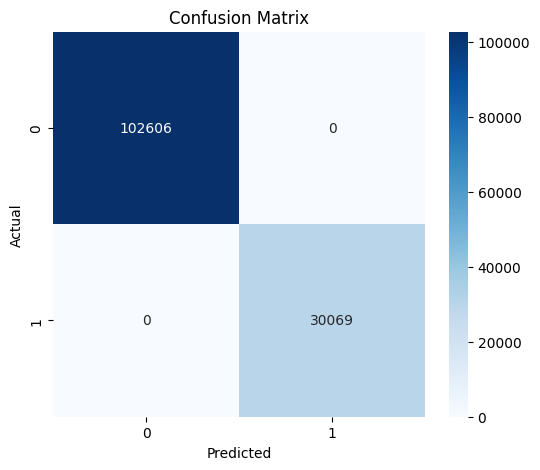

In [19]:
cm = confusion_matrix(

    y_test,

    y_pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [20]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
0,Recency,0.926189
1,Frequency,0.065007
2,Monetary,0.008804


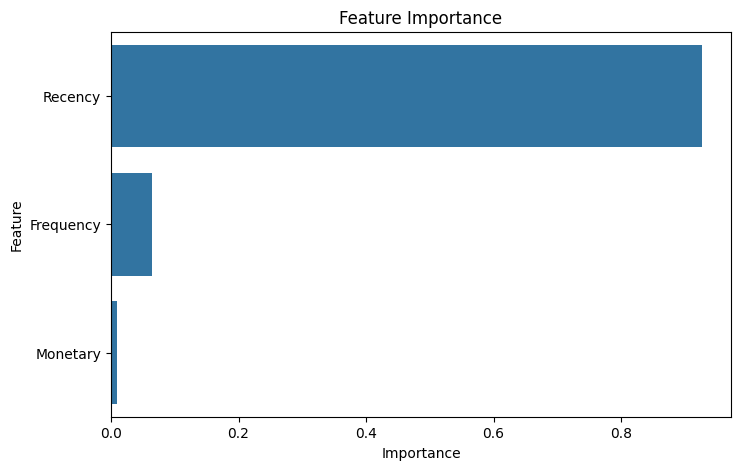

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance")

plt.show()

In [22]:
explainer = shap.TreeExplainer(

    best_model

)

shap_values = explainer.shap_values(

    X_test

)

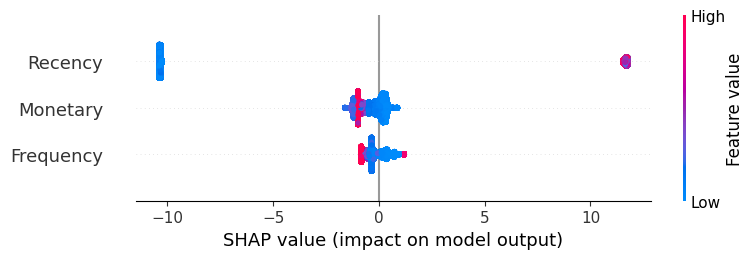

In [23]:
shap.summary_plot(

    shap_values,

    X_test
)

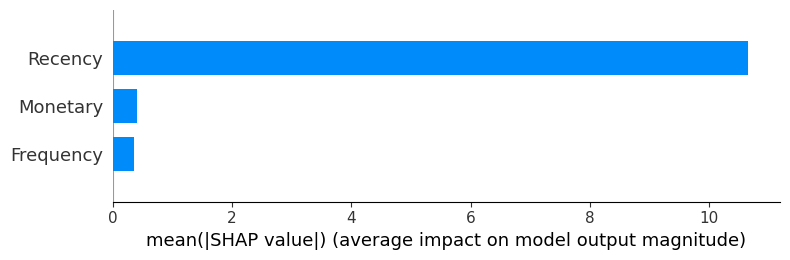

In [24]:
shap.summary_plot(

    shap_values,

    X_test,

    plot_type="bar"

)

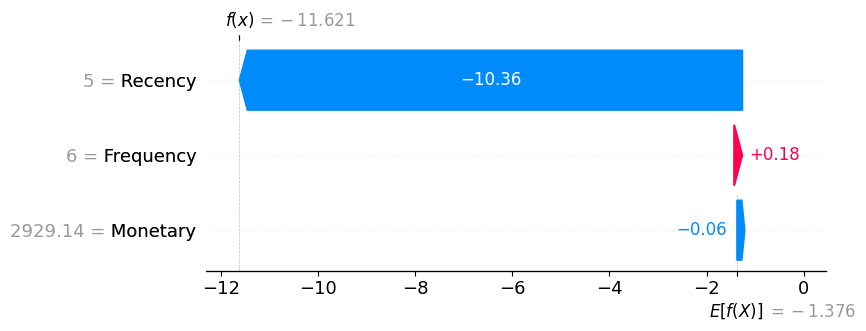

In [25]:
explanation = explainer(

    X_test

)

shap.plots.waterfall(

    explanation[0]

)

In [26]:
comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "ROC AUC"

    ],

    "Before Tuning":[

        0.91,

        0.90,

        0.88,

        0.93

    ],

    "After Tuning":[

        accuracy,

        precision,

        recall,

        roc

    ]

})

comparison

,Metric,Before Tuning,After Tuning
0,Accuracy,0.91,1.0
1,Precision,0.90,1.0
2,Recall,0.88,1.0
3,ROC AUC,0.93,1.0


In [27]:
importance.to_csv(

    "feature_importance.csv",

    index=False

)

comparison.to_csv(

    "optimal-tuning-results.csv",

    index=False

)

print("Files Saved Successfully")

Files Saved Successfully
